In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import sklearn
import random

In [28]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

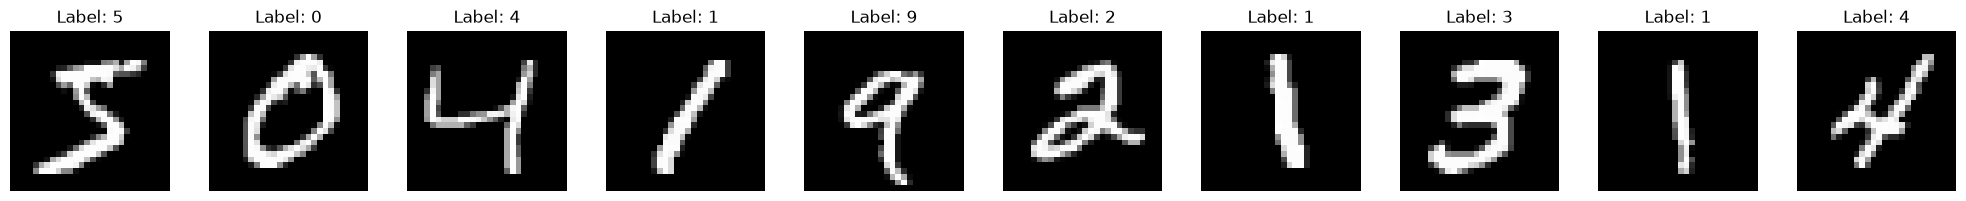

In [29]:
fig, ax = plt.subplots(1, 10, figsize=(20, 2))
ax = ax.flatten()

for i in range(10):
    image, label = train_data[i]

    ax[i].imshow(image.squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {label}")
    ax[i].set_axis_off()

plt.tight_layout()
plt.show()

In [40]:
X_train = train_data.data
y_train_full = train_data.targets.numpy()
X_test = test_data.data
y_test_full = test_data.targets.numpy()


X_train = X_train.reshape(X_train.shape[0], -1).float() / 255
X_test = X_test.reshape(X_test.shape[0], -1).float() / 255

import torch.nn.functional as F

y_train = F.one_hot(train_data.targets, num_classes=10).float()
y_test = F.one_hot(test_data.targets, num_classes=10).float()

In [52]:
class MnistDigitClassifier(torch.nn.Module):
    def __init__(self, input_size=784, hidden_size=128, output_size=10):
        super().__init__()
        self.input_layer = torch.nn.Linear(in_features=input_size, out_features=hidden_size)
        self.hidden_layer1 = torch.nn.Linear(in_features=hidden_size, out_features=hidden_size//2)
        self.output_layer = torch.nn.Linear(in_features=hidden_size//2, out_features=output_size)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        first = self.relu(self.input_layer(x))
        second = self.relu(self.hidden_layer1(first))
        third = self.output_layer(second)
        return third

In [53]:
model = MnistDigitClassifier()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=3)

epochs = 2000

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    acc = (y_pred.argmax(axis=1) == y_train_full).sum() * 100 / len(y_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model.eval()
        with torch.inference_mode():
            y_preds = model(X_test)
            loss_test = loss_fn(y_preds, y_test)
            acc_test = (y_preds.argmax(axis=1) == y_test_full).sum() * 100 / len(y_test)
 
        print(f"Epoch: {epoch}: loss = ({loss:.3f}, {loss_test:.3f}) | acc = ({acc:.3f}, {acc_test:.3f})")

Epoch: 0: loss = (0.115, 0.090) | acc = (7.350, 16.550)
Epoch: 100: loss = (0.023, 0.022) | acc = (89.417, 90.050)
Epoch: 200: loss = (0.015, 0.015) | acc = (93.242, 93.650)
Epoch: 300: loss = (0.013, 0.012) | acc = (94.643, 94.730)
Epoch: 400: loss = (0.011, 0.011) | acc = (95.598, 95.540)
Epoch: 500: loss = (0.010, 0.011) | acc = (95.943, 95.750)
Epoch: 600: loss = (0.009, 0.009) | acc = (96.505, 96.330)
Epoch: 700: loss = (0.008, 0.008) | acc = (97.018, 96.590)
Epoch: 800: loss = (0.007, 0.007) | acc = (97.325, 96.880)
Epoch: 900: loss = (0.007, 0.007) | acc = (97.523, 97.080)
Epoch: 1000: loss = (0.006, 0.007) | acc = (97.742, 97.130)
Epoch: 1100: loss = (0.006, 0.007) | acc = (97.807, 97.220)
Epoch: 1200: loss = (0.006, 0.007) | acc = (98.052, 97.390)
Epoch: 1300: loss = (0.005, 0.006) | acc = (98.205, 97.420)
Epoch: 1400: loss = (0.005, 0.006) | acc = (98.298, 97.410)
Epoch: 1500: loss = (0.005, 0.006) | acc = (98.410, 97.510)
Epoch: 1600: loss = (0.005, 0.006) | acc = (98.452, 9